# StormEngine — Stage 1: Encoder (SetConv)

This notebook implements the **SetConv Encoder** — Stage 1 of the StormEngine pipeline.

## Purpose
Convert sparse, irregular point observations into a consistent gridded representation `(C, H, W)` ready for the Vision Transformer Processor.

## Pre-training strategy
Since DPC FVG station data has no historical archive, pre-training is performed entirely on ERA5:
- **Input (sparse):** ERA5 standard variables (`msl`, `u10`, `v10`, `i10fg`) extracted at fixed station coordinates
- **Target (grid):** ERA5-Land variables (`t2m`, `tp`) as reconstruction ground truth

## Input files
| File | Content | Role |
|---|---|---|
| `data_0.nc` | ERA5-Land: `t2m` [K], `tp` [m] @ 9 km | **Target grid** |
| `data_stream-oper_stepType-instant.nc` | ERA5 standard: `msl`, `u10`, `v10`, `i10fg` @ 31 km | **Sparse input source** |
| `value_lat_lon_temp.csv` | ERA5 grid values `(VALUE, lon, lat)` | **Fixed station coordinate pool** |

---
## 0. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths
PATH_ERA5_LAND = '/Users/a1-6/CoursesCode/Sem4/GeoProject/StormEngine/era5_land_estracted/data_0.nc'
PATH_ERA5_STD  = '/Users/a1-6/CoursesCode/Sem4/GeoProject/StormEngine/era5_std_estracted/data_stream-oper_stepType-instant.nc'
PATH_CSV       = '/Users/a1-6/CoursesCode/Sem4/GeoProject/StormEngine/value_lat_lon_temp.csv'

# ── Domain bounding box (North-East Adriatic / FVG)
LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0

# ── Variables
VARS_INPUT   = ['msl', 'u10', 'v10', 'i10fg']   # ERA5 standard  -> sparse input
VARS_TARGET  = ['t2m', 'tp']                     # ERA5-Land      -> grid target
N_INPUT_VARS  = len(VARS_INPUT)
N_TARGET_VARS = len(VARS_TARGET)

# ── SetConv fixed station grid
N_STATION_POINTS = 20    # mirrors DPC FVG coastal station density

# ── Training hyperparameters
BATCH_SIZE    = 4
LEARNING_RATE = 1e-4
N_EPOCHS      = 40
HIDDEN_DIM    = 128
KERNEL_SIZE   = 5
SIGMA         = 0.05     # Gaussian pooling bandwidth

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {DEVICE}')
print(f'Input vars    : {VARS_INPUT}')
print(f'Target vars   : {VARS_TARGET}')

Device        : cpu
Input vars    : ['msl', 'u10', 'v10', 'i10fg']
Target vars   : ['t2m', 'tp']


---
## 1. Load ERA5 Data

In [2]:
# ERA5-Land (TARGET)
ds_land = xr.open_dataset(PATH_ERA5_LAND)
print('=== ERA5-Land ===')
print(ds_land)
for v in ds_land.data_vars:
    da = ds_land[v]
    print(f'  {v}: shape={da.shape}  units={da.attrs.get("units","?")}  '
          f'range=[{float(da.min()):.3f}, {float(da.max()):.3f}]')

=== ERA5-Land ===
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 72, latitude: 76, longitude: 81)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 576B 2025-12-25 ... 2025-12-27T23...
  * latitude    (latitude) float64 608B 46.5 46.4 46.3 46.2 ... 39.2 39.1 39.0
  * longitude   (longitude) float64 648B 12.0 12.1 12.2 12.3 ... 19.8 19.9 20.0
    expver      (valid_time) <U4 1kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB ...
    tp          (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-30T13:19 GRIB to CDM+CF via cfgrib-0.9.1...
  t2m: shape=(72, 76, 81)  units=K  range=[257.746, 289.356]
  tp: s

In [3]:
# ERA5 standard (INPUT)
ds_std = xr.open_dataset(PATH_ERA5_STD)
print('=== ERA5 standard ===')
print(ds_std)
for v in ds_std.data_vars:
    da = ds_std[v]
    print(f'  {v}: shape={da.shape}  units={da.attrs.get("units","?")}  '
          f'range=[{float(da.min()):.3f}, {float(da.max()):.3f}]')

=== ERA5 standard ===
<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 72, latitude: 31, longitude: 33)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 576B 2025-12-25 ... 2025-12-27T23...
  * latitude    (latitude) float64 248B 46.5 46.25 46.0 ... 39.5 39.25 39.0
  * longitude   (longitude) float64 264B 12.0 12.25 12.5 ... 19.5 19.75 20.0
    expver      (valid_time) <U4 1kB ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 295kB ...
    u10         (valid_time, latitude, longitude) float32 295kB ...
    v10         (valid_time, latitude, longitude) float32 295kB ...
    i10fg       (valid_time, latitude, longitude) float32 295kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history

In [4]:
# CSV — ERA5 grid with lat/lon (used to define fixed station coords)
df_csv = pd.read_csv(PATH_CSV)
print('=== CSV ===')
print(f'Shape: {df_csv.shape}')
print(f'Columns: {list(df_csv.columns)}')
print(f'Lat: {df_csv["lat"].min()} — {df_csv["lat"].max()}')
print(f'Lon: {df_csv["lon"].min()} — {df_csv["lon"].max()}')
print(f'VALUE (t2m K): {df_csv["VALUE"].min():.2f} — {df_csv["VALUE"].max():.2f}')
df_csv.head()

=== CSV ===
Shape: (1023, 3)
Columns: ['VALUE', 'lon', 'lat']
Lat: 39.0 — 46.5
Lon: 12.0 — 20.0
VALUE (t2m K): 272.49 — 294.90


,VALUE,lon,lat
0,272.977295,12.00,46.5
1,274.268311,12.25,46.5
2,274.291748,12.50,46.5
3,272.494873,12.75,46.5
4,274.123779,13.00,46.5


---
## 2. Unit Conversions

| Variable | Raw unit | Target unit | Formula |
|---|---|---|---|
| `t2m` | K | °C | `− 273.15` |
| `tp` | m | mm | `× 1000` |
| `msl` | Pa | hPa | `÷ 100` |
| `u10`, `v10`, `i10fg` | m/s | m/s | — |

In [5]:
def convert_land(ds):
    ds = ds.copy()
    if 't2m' in ds:
        ds['t2m'] = ds['t2m'] - 273.15
        ds['t2m'].attrs['units'] = 'C'
    if 'tp' in ds:
        ds['tp'] = ds['tp'] * 1000
        ds['tp'].attrs['units'] = 'mm'
    return ds

def convert_std(ds):
    ds = ds.copy()
    if 'msl' in ds:
        ds['msl'] = ds['msl'] / 100
        ds['msl'].attrs['units'] = 'hPa'
    return ds

ds_land = convert_land(ds_land)
ds_std  = convert_std(ds_std)

# CSV column
df_csv['t2m_celsius'] = df_csv['VALUE'] - 273.15

print('Unit conversions applied.')
for v in ds_land.data_vars:
    da = ds_land[v]
    print(f'  land/{v}: [{float(da.min()):.3f}, {float(da.max()):.3f}] {da.attrs.get("units","?")}')
for v in ds_std.data_vars:
    da = ds_std[v]
    print(f'  std/{v}: [{float(da.min()):.3f}, {float(da.max()):.3f}] {da.attrs.get("units","?")}')

Unit conversions applied.
  land/t2m: [-15.404, 16.206] C
  land/tp: [0.000, 47.207] mm
  std/msl: [1008.697, 1033.746] hPa
  std/u10: [-15.154, 8.101] m s**-1
  std/v10: [-12.226, 9.872] m s**-1
  std/i10fg: [0.560, 22.298] m s**-1


---
## 3. Define Fixed Station Coordinates

Select N=20 fixed points from the CSV grid, biased toward the FVG coastal area (lat >= 44.5).
These coordinates are fixed for the entire pre-training and fine-tuning phases.

Station coords shape: (20, 2)


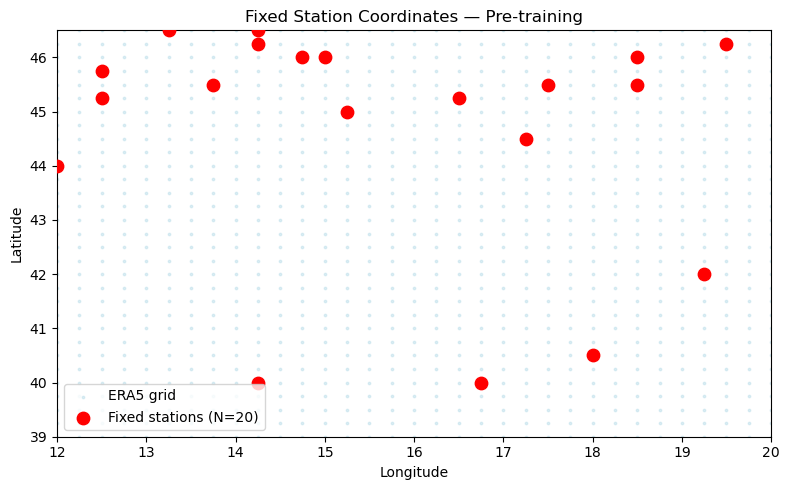

In [6]:
def select_station_coords(df, n=20, coastal_lat_min=44.5, seed=42):
    coastal = df[df['lat'] >= coastal_lat_min]
    inland  = df[df['lat'] <  coastal_lat_min]
    n_coast = min(int(n * 0.75), len(coastal))
    n_inl   = n - n_coast
    sel = pd.concat([
        coastal.sample(n=n_coast, random_state=seed),
        inland.sample(n=n_inl,   random_state=seed)
    ])
    return sel[['lat', 'lon']].values   # (N, 2)

STATION_COORDS = select_station_coords(df_csv, n=N_STATION_POINTS)
print(f'Station coords shape: {STATION_COORDS.shape}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_csv['lon'], df_csv['lat'], s=3, c='lightblue', alpha=0.4, label='ERA5 grid')
ax.scatter(STATION_COORDS[:, 1], STATION_COORDS[:, 0],
           s=80, c='red', zorder=5, label=f'Fixed stations (N={N_STATION_POINTS})')
ax.set(xlim=(LON_MIN, LON_MAX), ylim=(LAT_MIN, LAT_MAX),
       xlabel='Longitude', ylabel='Latitude',
       title='Fixed Station Coordinates — Pre-training')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. Normalisation

In [7]:
class Normalizer:
    """Per-variable z-score normalisation. Save stats for inference reuse."""
    def __init__(self):
        self.stats = {}

    def fit(self, data_dict):
        for name, arr in data_dict.items():
            m, s = float(np.nanmean(arr)), float(np.nanstd(arr)) + 1e-8
            self.stats[name] = (m, s)
            print(f'  {name}: mean={m:.4f}  std={s:.4f}')

    def transform(self, name, arr):
        m, s = self.stats[name]
        return (arr - m) / s

    def inverse_transform(self, name, arr):
        m, s = self.stats[name]
        return arr * s + m


t_coord = 'valid_time' if 'valid_time' in ds_std.coords else 'time'

print('Input normaliser (ERA5 standard):')
norm_input = Normalizer()
norm_input.fit({v: ds_std[v].values.flatten() for v in VARS_INPUT if v in ds_std})

print('\nTarget normaliser (ERA5-Land):')
norm_target = Normalizer()
norm_target.fit({v: ds_land[v].values.flatten() for v in VARS_TARGET if v in ds_land})

Input normaliser (ERA5 standard):
  msl: mean=1023.1279  std=4.8141
  u10: mean=-1.7270  std=3.2998
  v10: mean=-1.2556  std=2.7412
  i10fg: mean=6.8952  std=3.1695

Target normaliser (ERA5-Land):
  t2m: mean=3.3704  std=4.3157
  tp: mean=0.5630  std=1.6554


In [8]:
print("NaN check in ds_land:")
for v in VARS_TARGET:
    arr = ds_land[v].values
    print(v, "shape=", arr.shape,
          "n_nan=", np.isnan(arr).sum(),
          "has_nan=", np.isnan(arr).any())

print("\nNaN check in ds_std:")
for v in VARS_INPUT:
    arr = ds_std[v].values
    print(v, "shape=", arr.shape,
          "n_nan=", np.isnan(arr).sum(),
          "has_nan=", np.isnan(arr).any())

NaN check in ds_land:
t2m shape= (72, 76, 81) n_nan= 193680 has_nan= True
tp shape= (72, 76, 81) n_nan= 193680 has_nan= True

NaN check in ds_std:
msl shape= (72, 31, 33) n_nan= 0 has_nan= False
u10 shape= (72, 31, 33) n_nan= 0 has_nan= False
v10 shape= (72, 31, 33) n_nan= 0 has_nan= False
i10fg shape= (72, 31, 33) n_nan= 0 has_nan= False


---
## 5. PyTorch Dataset

In [9]:
ROUND1_CONFIGS = [
    {"sigma": 0.03, "hidden_dim": 64,  "lr": 1e-4, "epochs": 40},
    {"sigma": 0.03, "hidden_dim": 128, "lr": 1e-4, "epochs": 40},
    {"sigma": 0.03, "hidden_dim": 256, "lr": 1e-4, "epochs": 40},
    {"sigma": 0.05, "hidden_dim": 64,  "lr": 1e-4, "epochs": 40},
    {"sigma": 0.05, "hidden_dim": 128, "lr": 1e-4, "epochs": 40},
    {"sigma": 0.05, "hidden_dim": 256, "lr": 1e-4, "epochs": 40},
    {"sigma": 0.08, "hidden_dim": 64,  "lr": 1e-4, "epochs": 40},
    {"sigma": 0.08, "hidden_dim": 128, "lr": 1e-4, "epochs": 40},
    {"sigma": 0.08, "hidden_dim": 256, "lr": 1e-4, "epochs": 40},
]

In [10]:
class SetConvPretrainDataset(Dataset):
    """
    Pre-training dataset for the SetConv Encoder.

    Each sample:
      sparse_input : (N_stations, 2 + C_in)  lat/lon + ERA5 standard values
      target_grid  : (C_out, H, W)            ERA5-Land grid
    """

    def __init__(self, ds_std, ds_land, station_coords,
                 vars_input, vars_target, norm_input, norm_target):

        self.station_coords = station_coords
        self.vars_input     = vars_input
        self.vars_target    = vars_target
        self.norm_input     = norm_input
        self.norm_target    = norm_target

        t_coord = 'valid_time' if 'valid_time' in ds_std.coords else 'time'
        times_std  = ds_std[t_coord].values
        times_land = ds_land[t_coord].values
        self.times = np.intersect1d(times_std, times_land)
        print(f'Shared timestamps: {len(self.times)}')

        # Pre-load all into RAM
        self.std_arrays  = {v: ds_std[v].sel({t_coord: self.times}).values
                            for v in vars_input if v in ds_std}
        self.land_arrays = {v: ds_land[v].sel({t_coord: self.times}).values
                            for v in vars_target if v in ds_land}

        self.std_lats = ds_std['latitude'].values
        self.std_lons = ds_std['longitude'].values

        # Normalise station positions to [0,1]
        self.lat_norm = (station_coords[:, 0] - LAT_MIN) / (LAT_MAX - LAT_MIN)
        self.lon_norm = (station_coords[:, 1] - LON_MIN) / (LON_MAX - LON_MIN)

    def __len__(self):
        return len(self.times)

    def _extract_at_stations(self, t_idx):
        """Nearest-neighbour extraction of ERA5 standard at station coords."""
        out = np.zeros((len(self.station_coords), len(self.vars_input)), dtype=np.float32)
        for vi, v in enumerate(self.vars_input):
            if v not in self.std_arrays:
                continue
            field = self.std_arrays[v][t_idx]    # (H, W)
            for si, (lat, lon) in enumerate(self.station_coords):
                i = int(np.argmin(np.abs(self.std_lats - lat)))
                j = int(np.argmin(np.abs(self.std_lons - lon)))
                raw = float(field[i, j])
                out[si, vi] = float(self.norm_input.transform(v, np.array([raw]))[0])
        return out

    def _build_target(self, t_idx):
        """Stack ERA5-Land channels into (C, H, W)."""
        channels = []
        for v in self.vars_target:
            if v in self.land_arrays:
                f = self.land_arrays[v][t_idx].astype(np.float32)
                channels.append(self.norm_target.transform(v, f))
        return np.stack(channels, axis=0)

    def __getitem__(self, idx):
        vals = self._extract_at_stations(idx)                        # (N, C_in)
        pos  = np.stack([self.lat_norm, self.lon_norm], axis=1)      # (N, 2)
        x    = np.concatenate([pos, vals], axis=1)                   # (N, 2+C_in)
        y    = self._build_target(idx)                               # (C_out, H, W)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


dataset = SetConvPretrainDataset(
    ds_std=ds_std, ds_land=ds_land,
    station_coords=STATION_COORDS,
    vars_input=VARS_INPUT, vars_target=VARS_TARGET,
    norm_input=norm_input, norm_target=norm_target
)

x0, y0 = dataset[0]
print(f'Sample input  shape: {x0.shape}  (N_stations, 2+C_in)')
print(f'Sample target shape: {y0.shape} (C_out, H, W)')

Shared timestamps: 72
Sample input  shape: torch.Size([20, 6])  (N_stations, 2+C_in)
Sample target shape: torch.Size([2, 76, 81]) (C_out, H, W)


In [11]:
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

# time-order split: first 80% train, last 20% val
train_indices = list(range(n_train))
val_indices = list(range(n_train, n_total))

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

print(f"Total samples: {n_total}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples  : {len(val_dataset)}")

Total samples: 72
Train samples: 57
Val samples  : 15


In [12]:
x0, y0 = dataset[0]
print("x0 has NaN:", torch.isnan(x0).any().item())
print("y0 has NaN:", torch.isnan(y0).any().item())

for i, v in enumerate(VARS_TARGET):
    print(v, "NaN in target channel:", torch.isnan(y0[i]).any().item(),
          "count:", torch.isnan(y0[i]).sum().item())

x0 has NaN: False
y0 has NaN: True
t2m NaN in target channel: True count: 2690
tp NaN in target channel: True count: 2690


---
## 6. Visualise One Sample

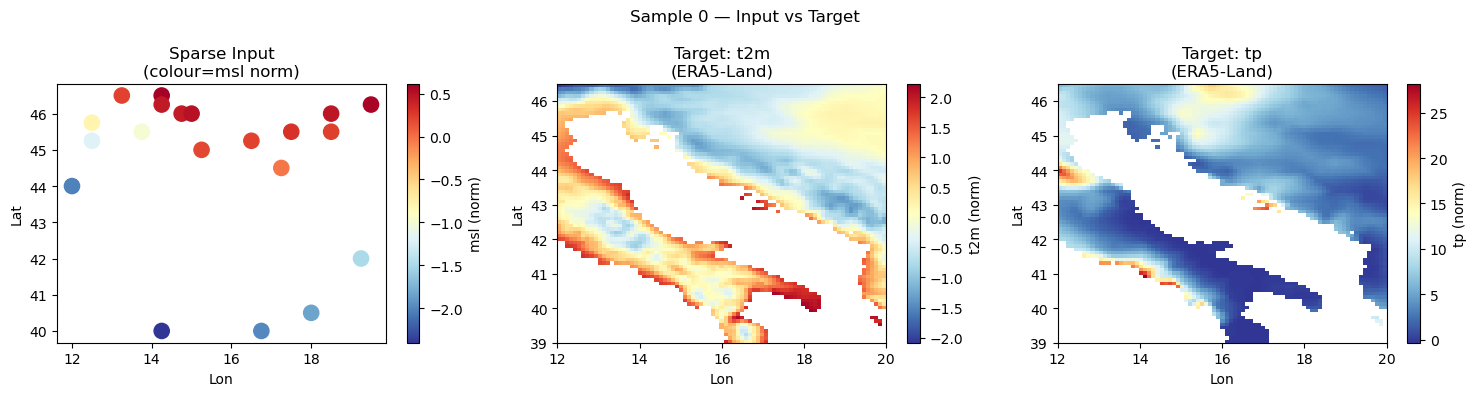

In [13]:
fig, axes = plt.subplots(1, N_TARGET_VARS + 1, figsize=(5*(N_TARGET_VARS+1), 4))

# Sparse input
sc = axes[0].scatter(
    x0[:, 1].numpy() * (LON_MAX-LON_MIN) + LON_MIN,
    x0[:, 0].numpy() * (LAT_MAX-LAT_MIN) + LAT_MIN,
    c=x0[:, 2].numpy(), cmap='RdYlBu_r', s=120, zorder=5)
plt.colorbar(sc, ax=axes[0], label='msl (norm)')
axes[0].set(title='Sparse Input\n(colour=msl norm)', xlabel='Lon', ylabel='Lat')

# Target channels
for i, v in enumerate(VARS_TARGET):
    target_vis = np.where(np.isfinite(y0[i].numpy()), y0[i].numpy(), np.nan)
    im = axes[i+1].imshow(target_vis, origin='upper', cmap='RdYlBu_r',
                          extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], aspect='auto')
    plt.colorbar(im, ax=axes[i+1], label=f'{v} (norm)')
    axes[i+1].set(title=f'Target: {v}\n(ERA5-Land)', xlabel='Lon', ylabel='Lat')

plt.suptitle('Sample 0 — Input vs Target', fontsize=12)
plt.tight_layout(); plt.show()

---
## 7. SetConv Model

```
sparse (B, N, 2+C_in)
      │
  PointEncoder (MLP per point)
      │ (B, N, hidden)
  GaussianPooling (distance-weighted aggregation)
      │ (B, hidden, H, W)
  GridDecoder (Conv2D)
      │
grid (B, C_out, H, W)
```

In [14]:
class PointEncoder(nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden)
        )
    def forward(self, x): return self.net(x)   # (B, N, hidden)


class GaussianPooling(nn.Module):
    """
    Aggregates sparse point features onto a regular grid using
    Gaussian distance-weighted averaging.
    """
    def __init__(self, H, W, sigma=0.15):
        super().__init__()
        self.H, self.W, self.sigma = H, W, sigma
        lats = torch.linspace(0, 1, H)
        lons = torch.linspace(0, 1, W)
        g_lat, g_lon = torch.meshgrid(lats, lons, indexing='ij')
        self.register_buffer('grid_pos', torch.stack([g_lat, g_lon], dim=-1))  # (H,W,2)

    def forward(self, point_pos, point_feat):
        # point_pos:  (B, N, 2)
        # point_feat: (B, N, D)
        B, N, D = point_feat.shape
        grid = self.grid_pos.view(-1, 2)                           # (H*W, 2)
        diff = point_pos.unsqueeze(2) - grid.unsqueeze(0).unsqueeze(0)  # (B,N,H*W,2)
        w = torch.exp(-(diff**2).sum(-1) / (2*self.sigma**2))     # (B,N,H*W)
        w = w / (w.sum(1, keepdim=True) + 1e-8)
        pooled = torch.bmm(point_feat.permute(0,2,1), w)          # (B,D,H*W)
        return pooled.view(B, D, self.H, self.W)


class GridDecoder(nn.Module):
    def __init__(self, hidden, out_ch, ks=5):
        super().__init__()
        p = ks//2
        self.net = nn.Sequential(
            nn.Conv2d(hidden, hidden, ks, padding=p), nn.ReLU(),
            nn.Conv2d(hidden, hidden//2, ks, padding=p), nn.ReLU(),
            nn.Conv2d(hidden//2, out_ch, 1)
        )
    def forward(self, x): return self.net(x)


class SetConvEncoder(nn.Module):
    def __init__(self, in_dim, hidden, out_ch, H, W, sigma=0.15, ks=5):
        super().__init__()
        self.pt_enc  = PointEncoder(in_dim, hidden)
        self.pool    = GaussianPooling(H, W, sigma)
        self.decoder = GridDecoder(hidden, out_ch, ks)

    def forward(self, x):
        # x: (B, N, 2+C_in)
        pos  = x[:, :, :2]              # (B, N, 2)
        feat = self.pt_enc(x)           # (B, N, hidden)
        grid = self.pool(pos, feat)     # (B, hidden, H, W)
        return self.decoder(grid)       # (B, C_out, H, W)




---
## 7. Infer target grid size

In [15]:

t_coord_land = 'valid_time' if 'valid_time' in ds_land.coords else 'time'
t0_land = ds_land[t_coord_land].values[0]
GRID_H, GRID_W = ds_land['t2m'].sel({t_coord_land: t0_land}).shape
print(f'Target grid: H={GRID_H}, W={GRID_W}')

Target grid: H=76, W=81


---
## 8. Loss function

In [16]:
def masked_mse(pred, target):
    """
    MSE computed only on valid (non-NaN) target pixels.

    ERA5-Land contains NaNs over sea regions (no land data),
    so we must ignore them during training and validation.
    """
    mask = torch.isfinite(target)
    if mask.sum() == 0:
        raise ValueError("All target pixels are NaN!")
    return ((pred[mask] - target[mask]) ** 2).mean()

---
## 9. Training function

In [17]:
def train_one_config(model, train_loader, val_loader, lr, n_epochs, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        # ---- train ----
        model.train()
        train_loss_sum = 0.0

        for xi, yi in train_loader:
            xi, yi = xi.to(device), yi.to(device)

            optimizer.zero_grad()
            pred = model(xi)
            loss = masked_mse(pred, yi)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()

        avg_train = train_loss_sum / len(train_loader)
        train_losses.append(avg_train)

        # ---- validation ----
        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for xi, yi in val_loader:
                xi, yi = xi.to(device), yi.to(device)
                pred = model(xi)
                loss = masked_mse(pred, yi)
                val_loss_sum += loss.item()

        avg_val = val_loss_sum / len(val_loader)
        val_losses.append(avg_val)

        scheduler.step(avg_val)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"Epoch [{epoch+1:3d}/{n_epochs}] "
                f"Train={avg_train:.6f}  Val={avg_val:.6f}  LR={current_lr:.2e}"
            )

    return train_losses, val_losses

---
## 10. Round-1 grid search

In [18]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

results = []
all_histories = {}

for cfg in ROUND1_CONFIGS:
    run_name = f"s{cfg['sigma']}_h{cfg['hidden_dim']}_lr{cfg['lr']}_e{cfg['epochs']}"
    print("\n" + "=" * 80)
    print(f"Running config: {run_name}")
    print("=" * 80)

    model = SetConvEncoder(
        in_dim=2 + N_INPUT_VARS,
        hidden=cfg["hidden_dim"],
        out_ch=N_TARGET_VARS,
        H=GRID_H,
        W=GRID_W,
        sigma=cfg["sigma"],
        ks=KERNEL_SIZE
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")

    train_losses, val_losses = train_one_config(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=cfg["lr"],
        n_epochs=cfg["epochs"],
        device=DEVICE
    )

    final_train = train_losses[-1]
    final_val = val_losses[-1]
    best_val = min(val_losses)
    best_epoch = int(np.argmin(val_losses)) + 1  # +1 so epoch count starts from 1

    results.append({
        "run_name": run_name,
        "sigma": cfg["sigma"],
        "hidden_dim": cfg["hidden_dim"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "final_train_loss": final_train,
        "final_val_loss": final_val,
        "best_val_loss": best_val,
        "best_epoch": best_epoch,
    })

    all_histories[run_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

results_df = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)

print("\n=== Round 1 Results (sorted by best_val_loss) ===")
print(results_df)

results_df.to_csv("round1_grid_search_results.csv", index=False)
print("\nSaved: round1_grid_search_results.csv")


Running config: s0.03_h64_lr0.0001_e40
Trainable parameters: 162,530
Epoch [  1/40] Train=1.088146  Val=0.501550  LR=1.00e-04
Epoch [  5/40] Train=0.874038  Val=0.406092  LR=1.00e-04
Epoch [ 10/40] Train=0.814824  Val=0.449752  LR=1.00e-04
Epoch [ 15/40] Train=0.820334  Val=0.455323  LR=5.00e-05
Epoch [ 20/40] Train=0.765925  Val=0.453222  LR=2.50e-05
Epoch [ 25/40] Train=0.795028  Val=0.462416  LR=1.25e-05
Epoch [ 30/40] Train=0.752254  Val=0.462620  LR=6.25e-06
Epoch [ 35/40] Train=0.752756  Val=0.468259  LR=3.13e-06
Epoch [ 40/40] Train=0.752749  Val=0.466517  LR=3.13e-06

Running config: s0.03_h128_lr0.0001_e40
Trainable parameters: 648,642
Epoch [  1/40] Train=1.067763  Val=0.394465  LR=1.00e-04
Epoch [  5/40] Train=0.828358  Val=0.379004  LR=1.00e-04
Epoch [ 10/40] Train=0.800284  Val=0.373345  LR=1.00e-04
Epoch [ 15/40] Train=0.758139  Val=0.418190  LR=1.00e-04
Epoch [ 20/40] Train=0.722679  Val=0.427853  LR=5.00e-05
Epoch [ 25/40] Train=0.700508  Val=0.417703  LR=2.50e-05
Epoc

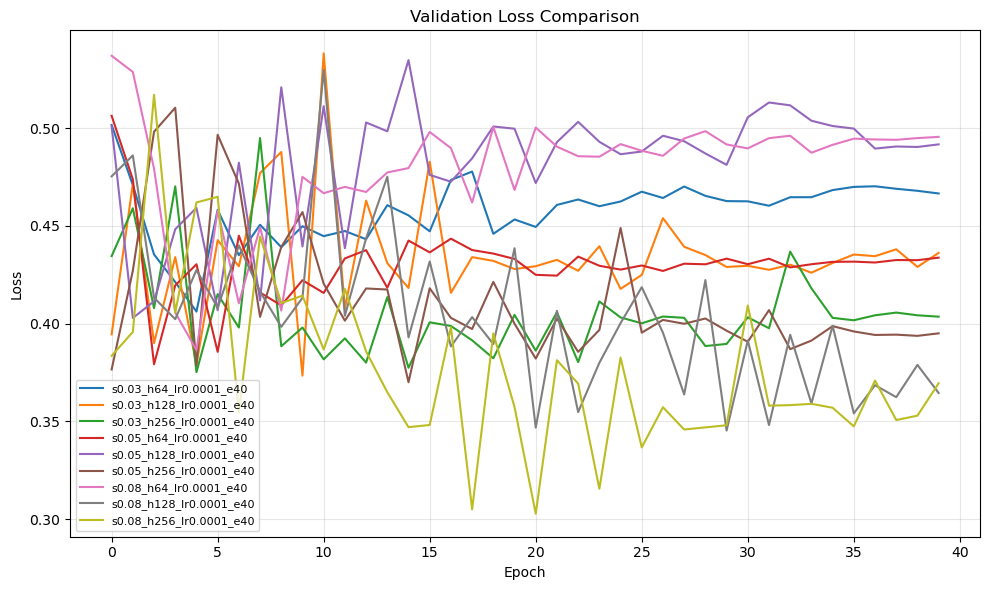

In [19]:
plt.figure(figsize=(10,6))

for run_name, history in all_histories.items():
    plt.plot(history["val_losses"], label=run_name)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

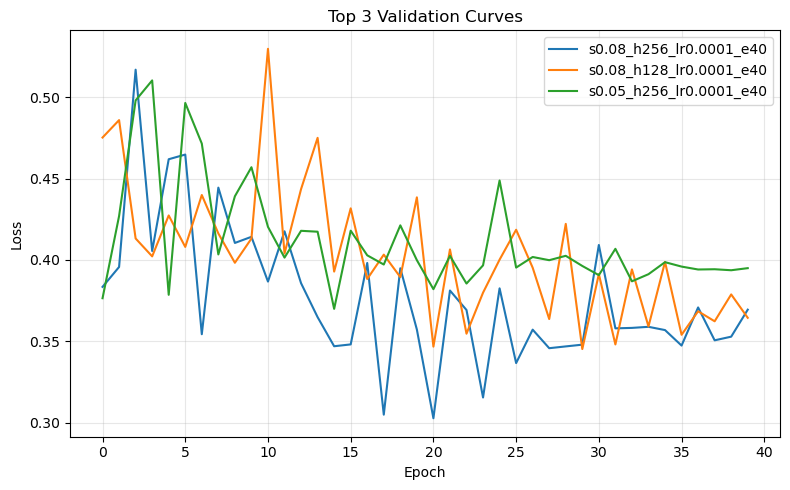

In [20]:
top_runs = results_df.head(3)["run_name"].tolist()

plt.figure(figsize=(8, 5))
for run_name in top_runs:
    history = all_histories[run_name]
    plt.plot(history["val_losses"], label=run_name)

plt.title("Top 3 Validation Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Plot validation ranking

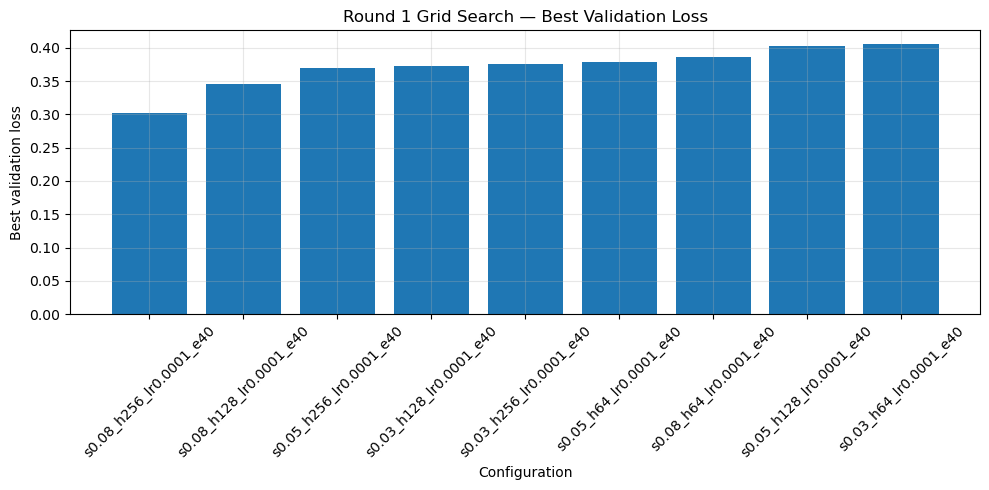

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results_df["run_name"], results_df["best_val_loss"])
ax.set_title("Round 1 Grid Search — Best Validation Loss")
ax.set_ylabel("Best validation loss")
ax.set_xlabel("Configuration")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Best configuration summary

In [22]:
best_cfg = results_df.iloc[0].to_dict()
print("\nBest configuration:")
for k, v in best_cfg.items():
    print(f"  {k}: {v}")


Best configuration:
  run_name: s0.08_h256_lr0.0001_e40
  sigma: 0.08
  hidden_dim: 256
  lr: 0.0001
  epochs: 40
  final_train_loss: 0.5264649202426275
  final_val_loss: 0.3694603890180588
  best_val_loss: 0.30272169783711433
  best_epoch: 21


---
## 12. Next Steps — Fine-tuning with DPC FVG Stations

Load the checkpoint and fine-tune on real DPC station CSV data.
The input format must match exactly:

| Requirement | Value |
|---|---|
| Input shape | `(B, N_stations, 2+C_in)` |
| Lat/lon | Normalised to [0,1] with same `LAT_MIN/MAX`, `LON_MIN/MAX` |
| Variable order | `msl, u10, v10, i10fg` |
| Units | `hPa, m/s, m/s, m/s` |
| Normalisation | Use `norm_input.stats` from checkpoint |

DPC → ERA5 variable mapping (from Parameters CrossMatch):
- `B` → `msl` (hPa)
- `Vv` → wind speed (m/s) → decompose to u/v components if available
- `VvMax` → `i10fg` (m/s)

```python
# Fine-tuning skeleton (02_encoder_finetuning.ipynb)
ckpt  = torch.load('setconv_pretrained.pt')
model = SetConvEncoder(**ckpt['model_config']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])

# Lower LR for fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
```